# Анализ продуктовой воронки

Анализ пользовательского пути в e-commerce продукте: построение воронки, оценка конверсий между этапами и поиск основных точек оттока пользователей.

## 1. Загрузка и проверка данных

In [84]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/customer_journey.csv')

df.head()

,SessionID,UserID,Timestamp,PageType,DeviceType,Country,ReferralSource,TimeOnPage_seconds,ItemsInCart,Purchased
0,session_0,user_2223,2025-01-20 22:53:34,home,Desktop,India,Social Media,55,0,0
1,session_1,user_2192,2025-02-26 12:57:10,home,Tablet,Germany,Email,99,0,0
2,session_1,user_2192,2025-02-26 12:59:11,product_page,Tablet,Germany,Email,121,0,0
3,session_2,user_1708,2025-06-24 15:40:46,home,Mobile,India,Google,160,0,0
4,session_3,user_2976,2025-06-11 07:21:02,home,Tablet,UK,Google,113,0,0


In [85]:
df.shape

(12719, 10)

In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12719 entries, 0 to 12718
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   SessionID           12719 non-null  object
 1   UserID              12719 non-null  object
 2   Timestamp           12719 non-null  object
 3   PageType            12719 non-null  object
 4   DeviceType          12719 non-null  object
 5   Country             12719 non-null  object
 6   ReferralSource      12719 non-null  object
 7   TimeOnPage_seconds  12719 non-null  int64 
 8   ItemsInCart         12719 non-null  int64 
 9   Purchased           12719 non-null  int64 
dtypes: int64(3), object(7)
memory usage: 993.8+ KB


In [87]:
df.columns.tolist()

['SessionID',
 'UserID',
 'Timestamp',
 'PageType',
 'DeviceType',
 'Country',
 'ReferralSource',
 'TimeOnPage_seconds',
 'ItemsInCart',
 'Purchased']

### Проверка качества данных

In [88]:
df.isna().sum()

SessionID             0
UserID                0
Timestamp             0
PageType              0
DeviceType            0
Country               0
ReferralSource        0
TimeOnPage_seconds    0
ItemsInCart           0
Purchased             0
dtype: int64

In [89]:
df.duplicated().sum()

np.int64(0)

In [90]:
df['SessionID'].nunique(), df['UserID'].nunique()

(5000, 1872)

In [91]:
df['PageType'].value_counts()

PageType
home            5000
product_page    3987
cart            1599
checkout        1123
confirmation    1010
Name: count, dtype: int64

In [92]:
for column in ['DeviceType', 'Country', 'ReferralSource']:
    print(f'\n{column}')
    print(df[column].value_counts())


DeviceType
DeviceType
Mobile     4256
Desktop    4240
Tablet     4223
Name: count, dtype: int64

Country
Country
France       1980
UK           1855
Canada       1825
USA          1808
India        1794
Germany      1738
Australia    1719
Name: count, dtype: int64

ReferralSource
ReferralSource
Google          3304
Email           3212
Social Media    3115
Direct          3088
Name: count, dtype: int64


In [93]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

df['Timestamp'].min(), df['Timestamp'].max()

(Timestamp('2025-01-01 00:09:11'), Timestamp('2025-08-31 23:51:09'))

In [94]:
df[['ItemsInCart', 'Purchased']].describe()

,ItemsInCart,Purchased
count,12719.000000,12719.000000
mean,1.138533,0.397044
std,1.689954,0.489304
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,2.000000,1.000000
max,5.000000,1.000000


### Результат проверки

Датасет содержит **12 719 событий**, относящихся к **5 000 сессиям** и **1 872 пользователям**. Период наблюдений — с января по август 2025 года.

Пропущенные значения и полные дубликаты отсутствуют. В данных представлены пять последовательных этапов пользовательского пути: `home`, `product_page`, `cart`, `checkout` и `confirmation`.

Данные позволяют построить воронку на уровне сессий и дополнительно сравнить её по типу устройства, источнику трафика и другим пользовательским сегментам.

## 2. Продуктовая воронка

Основная воронка:

**Home → Product page → Cart → Checkout → Confirmation**

Расчёт проводится на уровне сессий: каждая сессия учитывается на этапе не более одного раза.

In [95]:
# Порядок этапов воронки
funnel_steps = ['home', 'product_page', 'cart', 'checkout', 'confirmation']

# Оставляем только события, относящиеся к воронке
funnel_df = df[df['PageType'].isin(funnel_steps)].copy()

# Сортируем события внутри каждой сессии по времени
funnel_df = funnel_df.sort_values(['SessionID', 'Timestamp'])

funnel_df.head()

,SessionID,UserID,Timestamp,PageType,DeviceType,Country,ReferralSource,TimeOnPage_seconds,ItemsInCart,Purchased
0,session_0,user_2223,2025-01-20 22:53:34,home,Desktop,India,Social Media,55,0,0
1,session_1,user_2192,2025-02-26 12:57:10,home,Tablet,Germany,Email,99,0,0
2,session_1,user_2192,2025-02-26 12:59:11,product_page,Tablet,Germany,Email,121,0,0
20,session_10,user_2357,2025-05-17 22:11:37,home,Tablet,India,Direct,75,0,0
21,session_10,user_2357,2025-05-17 22:13:33,product_page,Tablet,India,Direct,116,0,0


In [96]:
# Проверяем, что в каждой сессии события идут в хронологическом порядке
funnel_df[['SessionID', 'Timestamp', 'PageType']].head(15)

,SessionID,Timestamp,PageType
0,session_0,2025-01-20 22:53:34,home
1,session_1,2025-02-26 12:57:10,home
2,session_1,2025-02-26 12:59:11,product_page
20,session_10,2025-05-17 22:11:37,home
21,session_10,2025-05-17 22:13:33,product_page
252,session_100,2025-04-02 11:24:36,home
253,session_100,2025-04-02 11:25:41,product_page
2504,session_1000,2025-08-25 09:34:15,home
2505,session_1000,2025-08-25 09:35:45,product_page
2506,session_1000,2025-08-25 09:38:16,cart


In [97]:
def get_funnel_progress(session):
    events = session['PageType'].tolist()
    
    reached_steps = []
    current_position = 0
    
    for event in events:
        if current_position < len(funnel_steps) and event == funnel_steps[current_position]:
            reached_steps.append(event)
            current_position += 1
    
    return reached_steps

In [98]:
session_progress = (
    funnel_df.groupby('SessionID')[['PageType']]
    .apply(get_funnel_progress)
)

session_progress.head()

SessionID
session_0                                                  [home]
session_1                                    [home, product_page]
session_10                                   [home, product_page]
session_100                                  [home, product_page]
session_1000    [home, product_page, cart, checkout, confirmat...
dtype: object

In [99]:
funnel_counts = {}

for step in funnel_steps:
    funnel_counts[step] = session_progress.apply(lambda x: step in x).sum()

funnel_counts

{'home': np.int64(5000),
 'product_page': np.int64(3987),
 'cart': np.int64(1599),
 'checkout': np.int64(1123),
 'confirmation': np.int64(1010)}

In [100]:
funnel_table = pd.DataFrame({
    'step': funnel_steps,
    'sessions': [funnel_counts[step] for step in funnel_steps]
})

funnel_table

,step,sessions
0,home,5000
1,product_page,3987
2,cart,1599
3,checkout,1123
4,confirmation,1010


In [101]:
funnel_table['step_conversion'] = funnel_table['sessions'] / funnel_table['sessions'].shift(1)
funnel_table['drop_off'] = 1 - funnel_table['step_conversion']

# Для первого этапа нет предыдущего шага
funnel_table.loc[0, 'step_conversion'] = 1
funnel_table.loc[0, 'drop_off'] = 0

funnel_table

,step,sessions,step_conversion,drop_off
0,home,5000,1.000000,0.000000
1,product_page,3987,0.797400,0.202600
2,cart,1599,0.401053,0.598947
3,checkout,1123,0.702314,0.297686
4,confirmation,1010,0.899377,0.100623


In [102]:
funnel_table_display = funnel_table.copy()

funnel_table_display['step_conversion_pct'] = (
    funnel_table_display['step_conversion'] * 100
).round(2)

funnel_table_display['drop_off_pct'] = (
    funnel_table_display['drop_off'] * 100
).round(2)

funnel_table_display[
    ['step', 'sessions', 'step_conversion_pct', 'drop_off_pct']
]

,step,sessions,step_conversion_pct,drop_off_pct
0,home,5000,100.00,0.00
1,product_page,3987,79.74,20.26
2,cart,1599,40.11,59.89
3,checkout,1123,70.23,29.77
4,confirmation,1010,89.94,10.06


In [103]:
overall_conversion = (
    funnel_table.loc[funnel_table['step'] == 'confirmation', 'sessions'].iloc[0]
    / funnel_table.loc[funnel_table['step'] == 'home', 'sessions'].iloc[0]
)

print(f'Общая конверсия Home → Confirmation: {overall_conversion:.2%}')

Общая конверсия Home → Confirmation: 20.20%


### Результаты воронки

Из 5 000 сессий до финального этапа `confirmation` дошли **1 010**, итоговая конверсия воронки составляет **20,20%**.

Конверсии между этапами:

- Home → Product page: **79,74%**
- Product page → Cart: **40,11%**
- Cart → Checkout: **70,23%**
- Checkout → Confirmation: **89,94%**

Наибольший отток наблюдается на переходе **Product page → Cart**: до корзины не доходят **59,89%** сессий, открывших страницу товара.

Этот этап является основной точкой потери пользователей в рассматриваемой воронке и требует отдельного продуктового исследования.

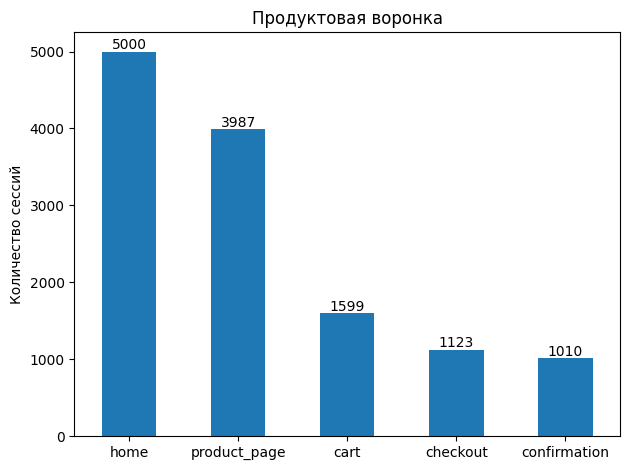

In [104]:
ax = funnel_table.plot(
    x='step',
    y='sessions',
    kind='bar',
    legend=False
)

ax.set_title('Продуктовая воронка')
ax.set_xlabel('')
ax.set_ylabel('Количество сессий')

for i, value in enumerate(funnel_table['sessions']):
    ax.text(i, value + 30, f'{value}', ha='center')

plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../images/funnel_sessions.png', dpi=150)
plt.show()

## 3. Сегментный анализ

Проверка воронки в разрезе типа устройства и источника трафика позволяет определить, связаны ли основные потери с отдельными пользовательскими сегментами.

In [105]:

session_features = (
    funnel_df.groupby('SessionID')
    .agg(
        DeviceType=('DeviceType', 'first'),
        ReferralSource=('ReferralSource', 'first'),
        Country=('Country', 'first'),
        SessionStart=('Timestamp', 'min')
    )
)

session_features.head()

,DeviceType,ReferralSource,Country,SessionStart
SessionID,,,,
session_0,Desktop,Social Media,India,2025-01-20 22:53:34
session_1,Tablet,Email,Germany,2025-02-26 12:57:10
session_10,Tablet,Direct,India,2025-05-17 22:11:37
session_100,Desktop,Email,USA,2025-04-02 11:24:36
session_1000,Mobile,Email,France,2025-08-25 09:34:15


In [106]:

for step in funnel_steps:
    session_features[step] = session_progress.apply(lambda x: step in x)

session_features.head()

,DeviceType,ReferralSource,Country,SessionStart,home,product_page,cart,checkout,confirmation
SessionID,,,,,,,,,
session_0,Desktop,Social Media,India,2025-01-20 22:53:34,True,False,False,False,False
session_1,Tablet,Email,Germany,2025-02-26 12:57:10,True,True,False,False,False
session_10,Tablet,Direct,India,2025-05-17 22:11:37,True,True,False,False,False
session_100,Desktop,Email,USA,2025-04-02 11:24:36,True,True,False,False,False
session_1000,Mobile,Email,France,2025-08-25 09:34:15,True,True,True,True,True


In [107]:
device_conversion = (
    session_features.groupby('DeviceType')['confirmation']
    .agg(['count', 'sum', 'mean'])
    .sort_values('mean', ascending=False)
)

device_conversion

,count,sum,mean
DeviceType,,,
Desktop,1666,339,0.203481
Mobile,1671,337,0.201676
Tablet,1663,334,0.200842


In [108]:
device_funnel = (
    session_features
    .groupby('DeviceType')[funnel_steps]
    .mean()
    * 100
)

device_funnel.round(2)

,home,product_page,cart,checkout,confirmation
DeviceType,,,,,
Desktop,100.0,79.29,31.75,23.11,20.35
Mobile,100.0,80.31,32.14,22.08,20.17
Tablet,100.0,79.62,32.05,22.19,20.08


In [109]:
device_step_conversion = device_funnel.copy()

for i in range(len(funnel_steps) - 1, 0, -1):
    current_step = funnel_steps[i]
    previous_step = funnel_steps[i - 1]
    
    device_step_conversion[current_step] = (
        device_funnel[current_step] / device_funnel[previous_step] * 100
    )

device_step_conversion['home'] = 100

device_step_conversion.round(2)

,home,product_page,cart,checkout,confirmation
DeviceType,,,,,
Desktop,100,79.29,40.05,72.78,88.05
Mobile,100,80.31,40.01,68.72,91.33
Tablet,100,79.62,40.26,69.23,90.51


### Тип устройства

Итоговая конверсия практически одинакова для разных устройств:

- Desktop — **20,35%**
- Mobile — **20,17%**
- Tablet — **20,08%**

Основная проблема сохраняется во всех трёх сегментах: конверсия **Product page → Cart** составляет около 40%.

На этапе Cart → Checkout Desktop показывает более высокую конверсию (**72,78%**) по сравнению с Mobile (**68,72%**) и Tablet (**69,23%**), однако различия в итоговой конверсии между устройствами невелики.

По имеющимся данным нельзя связать основной отток воронки с конкретным типом устройства.

In [110]:
referral_conversion = (
    session_features.groupby('ReferralSource')['confirmation']
    .agg(['count', 'sum', 'mean'])
    .sort_values('mean', ascending=False)
)

referral_conversion

,count,sum,mean
ReferralSource,,,
Google,1280,277,0.216406
Email,1251,251,0.200639
Direct,1226,243,0.198206
Social Media,1243,239,0.192277


In [111]:
referral_funnel = (
    session_features
    .groupby('ReferralSource')[funnel_steps]
    .mean()
    * 100
)

referral_funnel.round(2)

,home,product_page,cart,checkout,confirmation
ReferralSource,,,,,
Direct,100.0,78.79,31.48,21.78,19.82
Email,100.0,81.53,32.61,22.54,20.06
Google,100.0,79.22,33.36,23.91,21.64
Social Media,100.0,79.40,30.41,21.56,19.23


In [112]:
referral_step_conversion = referral_funnel.copy()

for i in range(len(funnel_steps) - 1, 0, -1):
    current_step = funnel_steps[i]
    previous_step = funnel_steps[i - 1]
    
    referral_step_conversion[current_step] = (
        referral_funnel[current_step] / referral_funnel[previous_step] * 100
    )

referral_step_conversion['home'] = 100

referral_step_conversion.round(2)

,home,product_page,cart,checkout,confirmation
ReferralSource,,,,,
Direct,100,78.79,39.96,69.17,91.01
Email,100,81.53,40.00,69.12,89.01
Google,100,79.22,42.11,71.66,90.52
Social Media,100,79.40,38.30,70.90,89.18


### Источник трафика

Наиболее высокая итоговая конверсия наблюдается у пользователей из Google — **21,64%**. Наименьшая — у Social Media: **19,23%**.

Основное различие также проявляется на переходе Product page → Cart:

- Google — **42,11%**
- Email — **40,00%**
- Direct — **39,96%**
- Social Media — **38,30%**

Пользователи из Google чаще остальных переходят со страницы товара в корзину, тогда как у Social Media этот показатель минимален.

Источник трафика связан с заметно большей вариативностью воронки, чем тип устройства. При дальнейшем анализе стоит отдельно изучить качество и намерение пользователей, приходящих из разных каналов.

In [113]:
session_features['month'] = session_features['SessionStart'].dt.to_period('M')

monthly_conversion = (
    session_features.groupby('month')['confirmation']
    .agg(['count', 'sum', 'mean'])
)

monthly_conversion

,count,sum,mean
month,,,
2025-01,657,126,0.191781
2025-02,593,110,0.185497
2025-03,630,135,0.214286
2025-04,564,118,0.209220
2025-05,634,129,0.203470
2025-06,630,128,0.203175
2025-07,656,133,0.202744
2025-08,636,131,0.205975


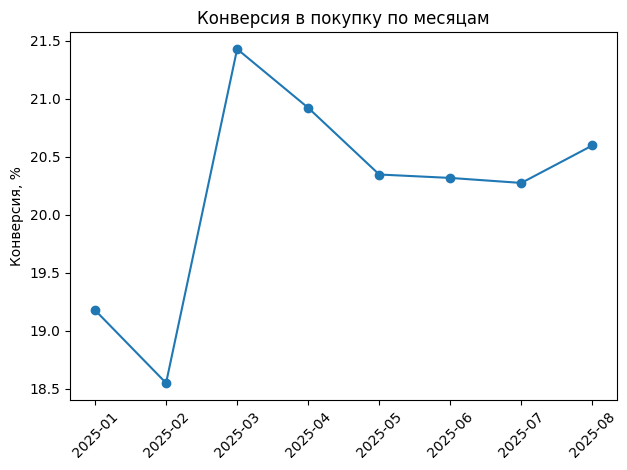

In [114]:
monthly_conversion_plot = monthly_conversion.copy()
monthly_conversion_plot.index = monthly_conversion_plot.index.astype(str)

ax = (monthly_conversion_plot['mean'] * 100).plot(
    kind='line',
    marker='o'
)

ax.set_title('Конверсия в покупку по месяцам')
ax.set_xlabel('')
ax.set_ylabel('Конверсия, %')

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../images/monthly_conversion.png', dpi=150)
plt.show()

## 4. Динамика конверсии

Конверсия в покупку в течение периода находится примерно в диапазоне **18,55–21,43%**.

Минимальное значение наблюдается в феврале — **18,55%**, максимальное в марте — **21,43%**. С мая по август показатель находится около 20–21% без выраженного тренда на снижение или рост.

Таким образом, основной отток воронки не выглядит следствием устойчивого ухудшения конверсии во времени.

In [115]:
purchase_check = (
    df.groupby('SessionID')
    .agg(
        purchased=('Purchased', 'max')
    )
)

purchase_check = purchase_check.join(
    session_features[['confirmation']]
)

pd.crosstab(
    purchase_check['confirmation'],
    purchase_check['purchased']
)

purchased,0,1
confirmation,,
False,3990,0
True,0,1010


### Проверка целевого события

Флаг `Purchased` полностью совпадает с достижением этапа `confirmation`: все 1 010 сессий с подтверждением покупки имеют `Purchased = 1`, а среди остальных сессий покупок нет.

Поэтому `confirmation` корректно используется как финальный этап продуктовой воронки.

## 5. Итоговый вывод

Итоговая конверсия из посещения главной страницы в подтверждённую покупку составляет **20,20%**.

Основная точка оттока — переход **Product page → Cart**. На этом этапе конверсия составляет только **40,11%**, а drop-off — **59,89%**. Остальные этапы проходят заметно лучше: Cart → Checkout — **70,23%**, Checkout → Confirmation — **89,94%**.

Сегментация по устройствам не выявила существенных различий в итоговой конверсии: Desktop, Mobile и Tablet находятся около 20%. При этом по источникам трафика различия заметнее: Google показывает итоговую конверсию **21,64%**, Social Media — **19,23%**. Максимальная разница между каналами также возникает на переходе Product page → Cart.

Конверсия по месяцам остаётся относительно стабильной и не показывает устойчивого негативного тренда.

Основной зоной для дальнейшего продуктового исследования является страница товара и переход к добавлению товара в корзину. В первую очередь стоит проверить удобство и заметность CTA, полноту информации о товаре, цену и условия доставки, технические ошибки добавления в корзину, а также различия в качестве трафика между Google и Social Media.

Данные позволяют определить проблемный этап воронки, но не объясняют причину поведения пользователей. Для подтверждения продуктовых гипотез потребуются дополнительные события интерфейса и дальнейшие эксперименты.